In [13]:
import os

import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')


# show(df_marises_hourly)

In [14]:
df_history_calefaccion=pd.read_csv("../../data/Sensores/History_2025-09-01_100-2026-03-02_1400.csv")

In [15]:
df_history_calefaccion

,date,time,temperature ℃,humidity %RH
0,2025.09.01,1:00,31.3,49.3
1,2025.09.01,2:00,31.1,46.2
2,2025.09.01,3:00,31.2,46.2
3,2025.09.01,4:00,31.2,46.0
4,2025.09.01,5:00,31.2,46.3
...,...,...,...,...
4377,2026.03.02,10:00,22.1,48.7
4378,2026.03.02,11:00,22.3,48.7
4379,2026.03.02,12:00,22.0,50.1
4380,2026.03.02,13:00,21.9,51.5


In [16]:
df_history_calefaccion.info()

# El history tiene en temperature y hymidity 57 valores NULL, lo que es un 4.75% de los datos. 
# No es un porcentaje muy alto, pero es importante tenerlo en cuenta a la hora de analizar los datos y tomar decisiones sobre cómo manejarlos.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4382 entries, 0 to 4381
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           4382 non-null   object
 1   time           4382 non-null   object
 2   temperature ℃  4382 non-null   object
 3   humidity %RH   4382 non-null   object
dtypes: object(4)
memory usage: 137.1+ KB


In [17]:
# Ahora voy a convertir las columnas de temperatura y humedad a formato numérico, para poder analizarlas mejor. 
# Primero, voy a eliminar los espacios en blanco de los nombres de las columnas, 
# luego voy a crear una nueva columna de datetime combinando las columnas de date y time, y 
# finalmente voy a convertir las columnas de temperatura y humedad a formato numérico, reemplazando las comas por puntos.

df_history_calefaccion.columns = df_history_calefaccion.columns.str.strip()

df_history_calefaccion["datetime"] = pd.to_datetime(
    df_history_calefaccion["date"] + " " + df_history_calefaccion["time"]
)

df_history_calefaccion = df_history_calefaccion.set_index("datetime")

df_history_calefaccion["temperature ℃"] = (
    df_history_calefaccion["temperature ℃"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df_history_calefaccion["humidity %RH"] = (
    df_history_calefaccion["humidity %RH"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df_history_calefaccion[["temperature ℃", "humidity %RH"]] = (
    df_history_calefaccion[["temperature ℃", "humidity %RH"]]
    .apply(pd.to_numeric, errors="coerce")
)

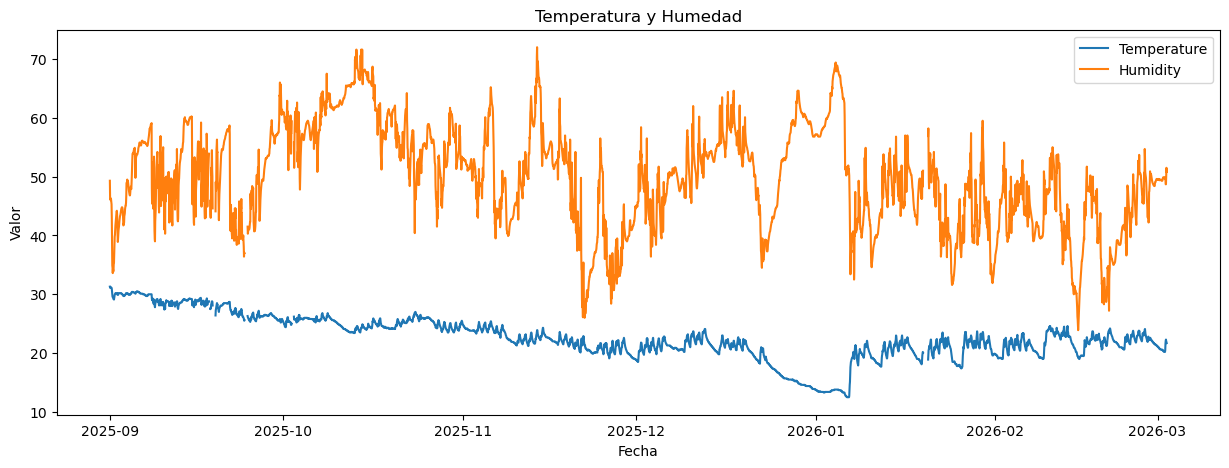

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Ahora voy a crear un gráfico de líneas para visualizar la evolución de la temperatura y la humedad a lo largo del tiempo.

plt.figure(figsize=(15,5))

plt.plot(df_history_calefaccion.index, df_history_calefaccion["temperature ℃"], label="Temperature")
plt.plot(df_history_calefaccion.index, df_history_calefaccion["humidity %RH"], label="Humidity")

plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.title("Temperatura y Humedad")
plt.legend()

plt.show()

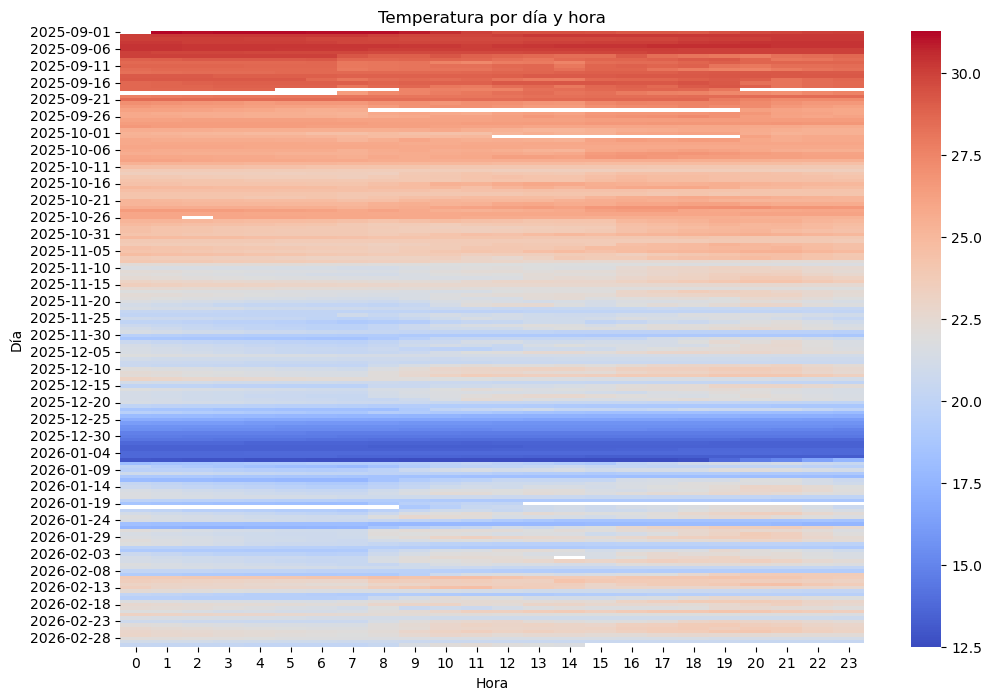

In [19]:
# Ahora voy a crear un gráfico de calor para visualizar la temperatura por día y hora.

df_plot = df_history_calefaccion.copy()
df_plot["day"] = df_plot.index.date
df_plot["hour"] = df_plot.index.hour

heatmap_data = df_plot.pivot_table(
    values="temperature ℃",
    index="day",
    columns="hour",
    aggfunc="mean"
)

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, cmap="coolwarm")

plt.title("Temperatura por día y hora")
plt.xlabel("Hora")
plt.ylabel("Día")

plt.show()

In [20]:
df_history_calefaccion

,date,time,temperature ℃,humidity %RH
datetime,,,,
2025-09-01 01:00:00,2025.09.01,1:00,31.3,49.3
2025-09-01 02:00:00,2025.09.01,2:00,31.1,46.2
2025-09-01 03:00:00,2025.09.01,3:00,31.2,46.2
2025-09-01 04:00:00,2025.09.01,4:00,31.2,46.0
2025-09-01 05:00:00,2025.09.01,5:00,31.2,46.3
...,...,...,...,...
2026-03-02 10:00:00,2026.03.02,10:00,22.1,48.7
2026-03-02 11:00:00,2026.03.02,11:00,22.3,48.7
2026-03-02 12:00:00,2026.03.02,12:00,22.0,50.1


In [21]:
df_temperature=pd.read_csv("../../data/lake/silver/temperatura.csv")
df_temperature

,timestamp,value,date,hour,weekday
0,2024-12-10 19:00:00+00:00,21.1,2024-12-10,19,1
1,2024-12-10 20:00:00+00:00,20.4,2024-12-10,20,1
2,2024-12-10 21:00:00+00:00,19.7,2024-12-10,21,1
3,2024-12-10 22:00:00+00:00,19.2,2024-12-10,22,1
4,2024-12-10 23:00:00+00:00,19.1,2024-12-10,23,1
...,...,...,...,...,...
10713,2026-03-02 04:00:00+00:00,18.0,2026-03-02,4,0
10714,2026-03-02 05:00:00+00:00,17.9,2026-03-02,5,0
10715,2026-03-02 06:00:00+00:00,18.0,2026-03-02,6,0
10716,2026-03-02 07:00:00+00:00,19.4,2026-03-02,7,0


In [29]:
df_history_calefaccion.index = df_history_calefaccion.index.tz_localize(None)
df_temperature["timestamp"] = pd.to_datetime(df_temperature["timestamp"])

In [31]:
# convertir timestamp a datetime
df_temperature["timestamp"] = pd.to_datetime(df_temperature["timestamp"])

# quitar timezone del índice del history
df_history_calefaccion.index = pd.to_datetime(df_history_calefaccion.index).tz_localize(None)

# asegurar que timestamp tampoco tenga timezone
df_temperature["timestamp"] = df_temperature["timestamp"].dt.tz_localize(None)

In [32]:
#vamos a unirlos df_temperature por la columna timestamp solo el value y df_history_calefaccion por la columna datetime solo el valor de la columan temperature ℃
df_data = (
    df_temperature.set_index("timestamp")[["value"]]
    .join(df_history_calefaccion[["temperature ℃"]], how="inner")
    .reset_index()
)

In [33]:
df_data

,index,value,temperature ℃
0,2025-09-01 01:00:00,NaN,31.3
1,2025-09-01 02:00:00,NaN,31.1
2,2025-09-01 03:00:00,NaN,31.2
3,2025-09-01 04:00:00,NaN,31.2
4,2025-09-01 05:00:00,NaN,31.2
...,...,...,...
4371,2026-03-02 04:00:00,18.0,20.2
4372,2026-03-02 05:00:00,17.9,20.2
4373,2026-03-02 06:00:00,18.0,20.2
4374,2026-03-02 07:00:00,19.4,20.2


In [40]:
#drop nulls NAN
df_data=df_data.dropna()
df_data = df_data.rename(columns={"temperature ℃": "target"})
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3925 entries, 394 to 4375
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   index   3925 non-null   datetime64[ns]
 1   value   3925 non-null   float64       
 2   target  3925 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 122.7 KB


# regresion lineal

In [41]:
X = df_data[["value"]]
y = df_data["target"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
y_pred = model.predict(X_test)

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.7523247119634265
RMSE: 0.9990923814388143
R2: 0.9112082197929089


MAE = 0.75
En promedio el modelo se equivoca menos de 1 grado, lo cual es muy razonable para temperatura.

RMSE = 0.99
Penaliza más los errores grandes.
pero tambéion esta por debajo de 1 °C, lo que indica que no hay muchos errores extremos.

R² = 0.91
El modelo explica el 91 % de la variabilidad de la temperatura.

In [53]:
import joblib, os
path="../../data/lake/silver/models"
modelname=f"{path}/modelo_regresion_temperatura.pkl"
if not os.path.exists(path):
    os.makedirs(path)

joblib.dump(model, modelname)

['../../data/lake/silver/models/modelo_regresion_temperatura.pkl']

In [54]:
model = joblib.load(modelname)

In [55]:
X_new = df_temperature[["value"]]

# filtrar solo filas válidas
mask = X_new["value"].notna()

# predecir solo esas
predicciones = model.predict(X_new.loc[mask])

# crear columna vacía
df_temperature["predicted_temperature"] = np.nan

# insertar predicciones en las filas correctas
df_temperature.loc[mask, "predicted_temperature"] = predicciones


In [56]:
df_temperature

,timestamp,value,date,hour,weekday,predicted_temperature
0,2024-12-10 19:00:00,21.1,2024-12-10,19,1,22.759337
1,2024-12-10 20:00:00,20.4,2024-12-10,20,1,22.176913
2,2024-12-10 21:00:00,19.7,2024-12-10,21,1,21.594490
3,2024-12-10 22:00:00,19.2,2024-12-10,22,1,21.178473
4,2024-12-10 23:00:00,19.1,2024-12-10,23,1,21.095269
...,...,...,...,...,...,...
10713,2026-03-02 04:00:00,18.0,2026-03-02,4,0,20.180032
10714,2026-03-02 05:00:00,17.9,2026-03-02,5,0,20.096829
10715,2026-03-02 06:00:00,18.0,2026-03-02,6,0,20.180032
10716,2026-03-02 07:00:00,19.4,2026-03-02,7,0,21.344880
